# Analysis: CPU vs GPU Performance Comparison

This notebook is the third in a three-notebook benchmark:

1. **`CPU_Baseline.ipynb`**: runs the pipeline on CPU and writes
   `results/timings_cpu.csv` plus `results/best_params.json`.
2. **`GPU_Solution.ipynb`**: runs the same pipeline on GPU using cuDF / cuML / XGBoost-GPU,
   reuses the hyperparameters from the CPU notebook, and writes `results/timings_gpu.csv`.
3. **`Analysis.ipynb`** (this one): joins the two CSVs, computes medians across the 3
   sweep runs, and generates the speedup tables and figures used in the report.

The two timing notebooks are structured as mirrors of each other so that any difference in
their CSVs is attributable to hardware, not to modelling choices. This notebook does the
comparison work.

**Inputs:** `results/timings_cpu.csv`, `results/timings_gpu.csv`, `results/best_params.json`.

**Outputs:** five PNG figures (`fig1_speedup_by_phase.png` through `fig5_h2d_amortisation.png`)
saved alongside the CSVs in `results/`, plus tables printed inline.

**Run this notebook after both sweep notebooks have completed.**

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Load & Validate Data](#2-load--validate-data)
3. [Median Aggregation](#3-median-aggregation)
4. [Speedup Table](#4-speedup-table)
5. [Figure 1: Speedup vs Dataset Size per Phase](#5-figure-1-speedup-vs-dataset-size-per-phase)
6. [Figure 2: Total Pipeline Time CPU vs GPU](#6-figure-2-total-pipeline-time-cpu-vs-gpu)
7. [Figure 3: FE vs Training vs Inference Speedup](#7-figure-3-fe-vs-training-vs-inference-speedup)
8. [Figure 4: HPO Speedup](#8-figure-4-hpo-speedup)
9. [Figure 5: H2D Amortisation](#9-figure-5-h2d-amortisation)
10. [CV Context Summary](#10-cv-context-summary)
11. [Full-Dataset Summary](#11-full-dataset-summary)

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Local-run fallback: when VS Code opens the notebook from Projects/, cwd is Projects/
# and the data is one level up. The Drive-mount cell below overrides this on Colab.
if os.path.basename(os.getcwd()) == 'Projects':
    os.chdir('..')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 130

# Phase constants
PHASE_ORDER = ['fe_train', 'fe_test', 'lr_fit', 'lr_predict', 'xgb_fit', 'xgb_predict']
PHASE_LABEL = {
    'fe_train':    'FE Train',
    'fe_test':     'FE Test',
    'lr_fit':      'LR Fit',
    'lr_predict':  'LR Predict',
    'xgb_fit':     'XGB Fit',
    'xgb_predict': 'XGB Predict',
}
HPO_PHASES = ['lr_cv', 'xgb_cv']
HPO_LABEL  = {'lr_cv': 'LR CV', 'xgb_cv': 'XGB CV'}
FRACS      = [0.10, 0.25, 0.50, 0.75, 1.00]
HPO_FRACS  = [0.25, 0.50, 1.00]
PCT        = [f'{int(f*100)}%' for f in FRACS]

# Stage groupings for Figure 3.
# FE is its own stage; Training = fits only; Inference = predicts only.
FE_PHASES        = ['fe_train',   'fe_test']
TRAINING_PHASES  = ['lr_fit',     'xgb_fit']
INFERENCE_PHASES = ['lr_predict', 'xgb_predict']

# Consistent colour palette: same phase keeps the same colour in every figure.
PHASE_COLORS = {
    'fe_train':    '#4C72B0',
    'fe_test':     '#64B5CD',
    'lr_fit':      '#55A868',
    'lr_predict':  '#90C06A',
    'xgb_fit':     '#C44E52',
    'xgb_predict': '#E08C8C',
}
STAGE_COLORS = {
    'Feature Eng.':   '#4C72B0',
    'Model Training': '#55A868',
    'Model Inference':'#C44E52',
}
HPO_COLORS = {'lr_cv': '#55A868', 'xgb_cv': '#C44E52'}

In [2]:
# Mount Google Drive and point to the results folder produced by the sweep notebooks.
# Skips automatically if not running on Colab (e.g. local re-run from VS Code).
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # EDIT THIS PATH if your project root on Drive is somewhere else.
    # The folder must contain results/timings_cpu.csv, results/timings_gpu.csv,
    # and results/best_params.json (the outputs of the sweep notebooks).
    REPO_ROOT = '/content/drive/MyDrive'
    os.chdir(REPO_ROOT)
    print(f'Working directory set to: {os.getcwd()}')
except ModuleNotFoundError:
    # Local fallback: keep the VS Code behaviour from the imports cell.
    print(f'Local run, working directory: {os.getcwd()}')

Local run, working directory: /home/claude


## 2. Load & Validate Data

Both CSVs share the schema `device, fraction, n_rows, phase, run_idx, seconds, notes`.

- **Main sweep rows** (`phase` in `PHASE_ORDER`): 3 runs × 5 fractions × 6 phases = 90 rows
  per device.
- **HPO rows** (`phase` in `{lr_cv, xgb_cv}`): the CPU notebook produces 6 rows
  (3 fractions × 2 phases); the GPU notebook produces 5 rows (`xgb_cv` is dropped at 25%).
  The HPO figure inner-joins on the fractions present in both.

`best_params.json` is read for the CV context timings and the H2D amortisation result.
The optional keys (`h2d_amortisation`, `xgb_randomizedsearch_gpu`) are only present after
`GPU_Solution.ipynb` finishes; if they are missing, the corresponding figures are skipped
gracefully.

In [3]:
cpu_raw = pd.read_csv('results/timings_cpu.csv')
gpu_raw = pd.read_csv('results/timings_gpu.csv')

# Separate main sweep from HPO rows
cpu = cpu_raw[cpu_raw['phase'].isin(PHASE_ORDER)].copy()
gpu = gpu_raw[gpu_raw['phase'].isin(PHASE_ORDER)].copy()

cpu_hpo = cpu_raw[cpu_raw['phase'].isin(HPO_PHASES)].copy()
gpu_hpo = gpu_raw[gpu_raw['phase'].isin(HPO_PHASES)].copy()

# CPU has 6 HPO rows (3 fracs x 2 phases); GPU has 5 (xgb_cv skipped at 25%). Accept either.
hpo_available = (len(cpu_hpo) >= 4) and (len(gpu_hpo) >= 4)

print(f'CPU main sweep : {len(cpu):>4} rows  (expected 90)')
print(f'GPU main sweep : {len(gpu):>4} rows  (expected 90)')
print(f'CPU HPO        : {len(cpu_hpo):>4} rows  (expected  6)  {"OK" if len(cpu_hpo)==6 else "not yet available"}')
print(f'GPU HPO        : {len(gpu_hpo):>4} rows  (expected  5)  {"OK" if len(gpu_hpo)>=5 else "not yet available"}')

assert len(cpu) == 90, f'CPU sweep: expected 90 rows, got {len(cpu)}'
assert len(gpu) == 90, f'GPU sweep: expected 90 rows, got {len(gpu)}'

# Load best_params.json. Fall back to a sibling copy at the repo root if needed.
_bp_candidates = ['results/best_params.json', 'best_params (1).json', 'best_params.json']
_bp_path = next((p for p in _bp_candidates if os.path.exists(p)), None)
if _bp_path is None:
    raise FileNotFoundError(
        'best_params JSON not found. Expected results/best_params.json or best_params (1).json'
    )
with open(_bp_path) as f:
    bp = json.load(f)

h2d_available    = 'h2d_amortisation' in bp
gpu_cv_available = 'xgb_randomizedsearch_gpu' in bp.get('cv_context_seconds', {})

print(f'\nbest_params JSON loaded from : {_bp_path}')
print(f'best_params.json  h2d_amortisation      : {"present" if h2d_available else "not yet available"}')
print(f'best_params.json  xgb_cv_gpu time       : {"present" if gpu_cv_available else "not yet available"}')

CPU main sweep :   90 rows  (expected 90)
GPU main sweep :   90 rows  (expected 90)
CPU HPO        :    6 rows  (expected  6)  OK
GPU HPO        :    5 rows  (expected  5)  OK

best_params JSON loaded from : results/best_params.json
best_params.json  h2d_amortisation      : present
best_params.json  xgb_cv_gpu time       : present


## 3. Median Aggregation

Reduce the 3-run raw timings to a single median per `(fraction, phase)` pair. The median
is more robust to outliers (warm-up spikes, scheduler noise) than the mean.

In [4]:
cpu_med = cpu.groupby(['fraction', 'phase'])['seconds'].median().rename('cpu_s')
gpu_med = gpu.groupby(['fraction', 'phase'])['seconds'].median().rename('gpu_s')

df = pd.concat([cpu_med, gpu_med], axis=1).reset_index()
df['speedup'] = df['cpu_s'] / df['gpu_s']
df['phase']   = pd.Categorical(df['phase'], categories=PHASE_ORDER, ordered=True)
df = df.sort_values(['fraction', 'phase']).reset_index(drop=True)

print(df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

 fraction       phase   cpu_s  gpu_s  speedup
   0.1000    fe_train  0.8340 0.5933   1.4057
   0.1000     fe_test  1.8870 1.1414   1.6532
   0.1000      lr_fit  0.7930 0.1222   6.4894
   0.1000  lr_predict  0.1190 0.0381   3.1234
   0.1000     xgb_fit  5.6800 0.9512   5.9714
   0.1000 xgb_predict  0.7530 0.1014   7.4260
   0.2500    fe_train  2.2960 1.2881   1.7825
   0.2500     fe_test  1.8260 1.2624   1.4465
   0.2500      lr_fit  1.5100 0.3968   3.8054
   0.2500  lr_predict  0.1040 0.0431   2.4130
   0.2500     xgb_fit  8.3670 1.7625   4.7472
   0.2500 xgb_predict  0.6930 0.1079   6.4226
   0.5000    fe_train  3.7300 2.1921   1.7016
   0.5000     fe_test  1.7830 1.1549   1.5439
   0.5000      lr_fit  4.1950 0.7168   5.8524
   0.5000  lr_predict  0.1050 0.0399   2.6316
   0.5000     xgb_fit 11.8370 2.2175   5.3380
   0.5000 xgb_predict  0.7060 0.1067   6.6167
   0.7500    fe_train  7.5170 3.2782   2.2930
   0.7500     fe_test  1.8210 1.2481   1.4590
   0.7500      lr_fit  4.3610 1.47

## 4. Speedup Table

The primary table for the report. Rows are dataset fractions, columns are pipeline phases.
Values > 1 mean the GPU is faster; values < 1 mean the GPU is slower (overhead-dominated).
The background gradient highlights where the speedup is largest.

In [5]:
pivot = df.pivot(index='fraction', columns='phase', values='speedup')[PHASE_ORDER]
pivot.index   = [f'{int(f*100)}%' for f in pivot.index]
pivot.columns = [PHASE_LABEL[c] for c in pivot.columns]

print('Speedup Table  (CPU median / GPU median, 3 runs)')
print('Values > 1  =>  GPU faster   |   Values < 1  =>  GPU slower\n')
print(pivot.round(2).to_string())

# Styled inline rendering (rendered in Jupyter / Colab)
(pivot.round(2)
      .style
      .background_gradient(cmap='RdYlGn', axis=None, vmin=0.5, vmax=6.0)
      .format(lambda v: f'{v:.2f}x')
      .set_caption('Speedup — 1x = break-even, >1x = GPU faster'))

Speedup Table  (CPU median / GPU median, 3 runs)
Values > 1  =>  GPU faster   |   Values < 1  =>  GPU slower

      FE Train  FE Test  LR Fit  LR Predict  XGB Fit  XGB Predict
10%       1.41     1.65    6.49        3.12     5.97         7.43
25%       1.78     1.45    3.81        2.41     4.75         6.42
50%       1.70     1.54    5.85        2.63     5.34         6.62
75%       2.29     1.46    2.96        1.86     5.09         9.55
100%      2.22     1.62    4.63        3.07     4.89         4.66


,FE Train,FE Test,LR Fit,LR Predict,XGB Fit,XGB Predict
10%,1.41x,1.65x,6.49x,3.12x,5.97x,7.43x
25%,1.78x,1.45x,3.81x,2.41x,4.75x,6.42x
50%,1.70x,1.54x,5.85x,2.63x,5.34x,6.62x
75%,2.29x,1.46x,2.96x,1.86x,5.09x,9.55x
100%,2.22x,1.62x,4.63x,3.07x,4.89x,4.66x


## 5. Figure 1: Speedup vs Dataset Size per Phase

Six lines, one per pipeline phase. The break-even dashed line at 1x separates the GPU-wins
from the CPU-wins. We expect bandwidth-bound phases (FE, with its string ops and
groupbys) to show a different scaling curve from compute-bound phases (XGBoost fit, where
tree construction is the bottleneck).

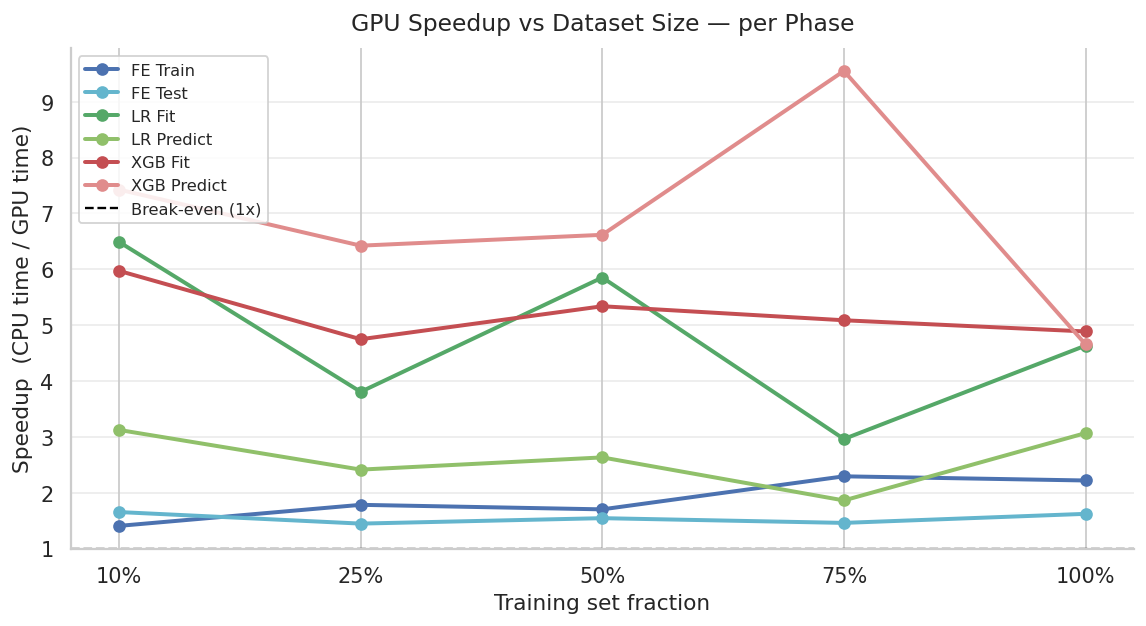

Saved  results/fig1_speedup_by_phase.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for phase in PHASE_ORDER:
    sub = df[df['phase'] == phase].sort_values('fraction')
    ax.plot(
        [f'{int(f*100)}%' for f in sub['fraction']],
        sub['speedup'],
        marker='o', linewidth=2.2, markersize=6,
        label=PHASE_LABEL[phase], color=PHASE_COLORS[phase]
    )

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.3, label='Break-even (1x)')
ax.set_xlabel('Training set fraction', fontsize=12)
ax.set_ylabel('Speedup  (CPU time / GPU time)', fontsize=12)
ax.set_title('GPU Speedup vs Dataset Size — per Phase', fontsize=13, pad=10)
ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
ax.grid(which='major', axis='y', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/fig1_speedup_by_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved  results/fig1_speedup_by_phase.png')

## 6. Figure 2: Total Pipeline Time CPU vs GPU

Grouped stacked bars: CPU (solid) vs GPU (faded), coloured by phase. Absolute time labels
above each bar show the full pipeline cost at each scale, making the end-to-end wall-clock
saving concrete.

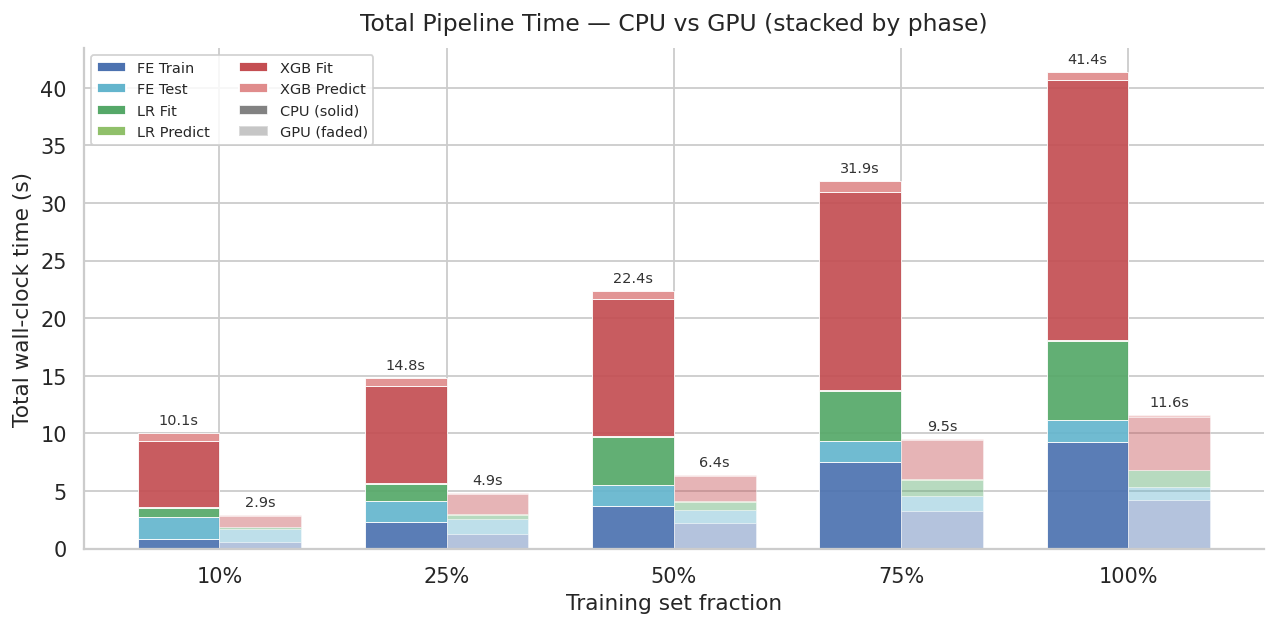

Saved  results/fig2_pipeline_time_bar.png


In [7]:
cpu_totals = (cpu.groupby(['fraction', 'phase'])['seconds']
                 .median().unstack(fill_value=0)[PHASE_ORDER])
gpu_totals = (gpu.groupby(['fraction', 'phase'])['seconds']
                 .median().unstack(fill_value=0)[PHASE_ORDER])

x = np.arange(len(FRACS))
w = 0.36
fig, ax = plt.subplots(figsize=(10, 5))
bottom_cpu = np.zeros(len(FRACS))
bottom_gpu = np.zeros(len(FRACS))

for phase in PHASE_ORDER:
    c_vals = cpu_totals[phase].values
    g_vals = gpu_totals[phase].values
    ax.bar(x - w/2, c_vals, w, bottom=bottom_cpu,
           color=PHASE_COLORS[phase], alpha=0.92, edgecolor='white', linewidth=0.5)
    ax.bar(x + w/2, g_vals, w, bottom=bottom_gpu,
           color=PHASE_COLORS[phase], alpha=0.42, edgecolor='white', linewidth=0.5)
    bottom_cpu += c_vals
    bottom_gpu += g_vals

# Total time labels above each bar
y_offset = max(bottom_cpu.max(), bottom_gpu.max()) * 0.012
for i, (c, g) in enumerate(zip(bottom_cpu, bottom_gpu)):
    ax.text(x[i] - w/2, c + y_offset, f'{c:.1f}s',
            ha='center', va='bottom', fontsize=8, color='#333333')
    ax.text(x[i] + w/2, g + y_offset, f'{g:.1f}s',
            ha='center', va='bottom', fontsize=8, color='#333333')

legend_phases = [mpatches.Patch(facecolor=PHASE_COLORS[p], label=PHASE_LABEL[p])
                 for p in PHASE_ORDER]
legend_device = [mpatches.Patch(facecolor='#777777', alpha=0.92, label='CPU (solid)'),
                 mpatches.Patch(facecolor='#777777', alpha=0.42, label='GPU (faded)')]
ax.legend(handles=legend_phases + legend_device,
          fontsize=8, loc='upper left', ncol=2, framealpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(PCT)
ax.set_xlabel('Training set fraction', fontsize=12)
ax.set_ylabel('Total wall-clock time (s)', fontsize=12)
ax.set_title('Total Pipeline Time — CPU vs GPU (stacked by phase)', fontsize=13, pad=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/fig2_pipeline_time_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved  results/fig2_pipeline_time_bar.png')

## 7. Figure 3: FE vs Training vs Inference Speedup

We split the pipeline into three stages so the training and inference speedups are visible
separately, and so feature engineering doesn't get hidden inside an end-to-end number. The
three stages have different performance profiles (FE is largely string-processing and
groupby work; XGBoost training is tree construction; inference is small batches with a
fixed model), and they scale differently with dataset size.

**Stage definitions:**

- **Feature Eng.**: `fe_train` + `fe_test` (cuDF string ops, groupby target encoding).
- **Model Training**: `lr_fit` + `xgb_fit` (cuML LR, GPU XGBoost).
- **Model Inference**: `lr_predict` + `xgb_predict`.

**Speedup formula:** sum of CPU medians for the phases in the group / sum of GPU medians
for the same phases.

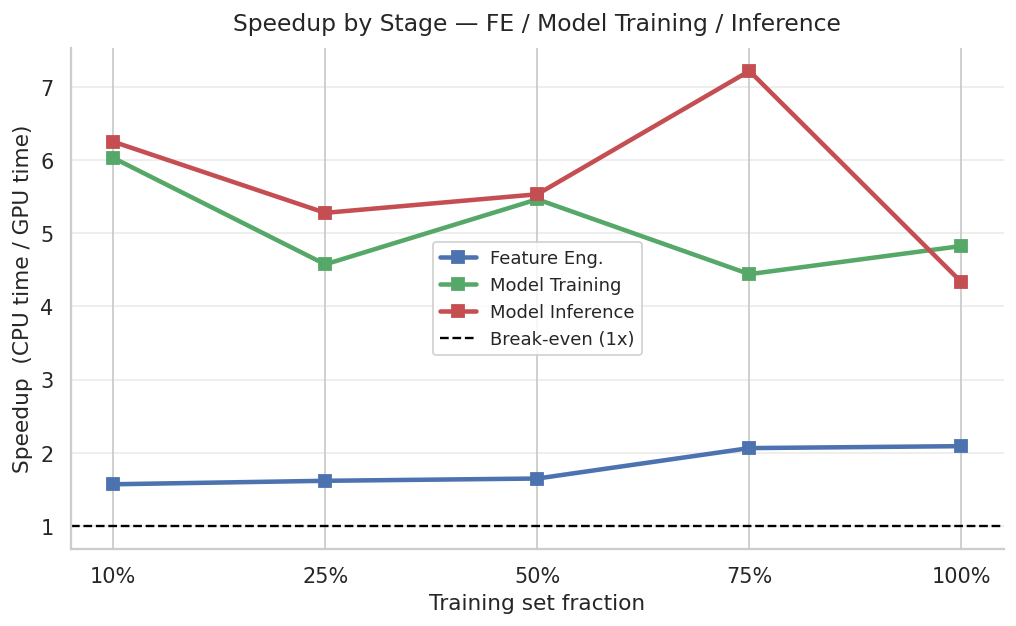

Saved  results/fig3_stage_speedup.png

Stage speedup  (CPU / GPU, summed medians over phases in group)
Stage                  10%   25%   50%   75%  100%
----------------------------------------------
Feature Eng.          1.57x  1.62x  1.65x  2.06x  2.09x
Model Training        6.03x  4.57x  5.46x  4.44x  4.82x
Model Inference       6.25x  5.28x  5.53x  7.22x  4.33x


In [8]:
stage_rows = []
for frac in FRACS:
    sub = df[df['fraction'] == frac]
    for stage, phases in [
        ('Feature Eng.',   FE_PHASES),
        ('Model Training', TRAINING_PHASES),
        ('Model Inference',INFERENCE_PHASES),
    ]:
        cpu_t = sub.loc[sub['phase'].isin(phases), 'cpu_s'].sum()
        gpu_t = sub.loc[sub['phase'].isin(phases), 'gpu_s'].sum()
        stage_rows.append({
            'fraction': frac, 'stage': stage,
            'cpu_s': cpu_t, 'gpu_s': gpu_t,
            'speedup': cpu_t / gpu_t if gpu_t > 0 else float('nan'),
        })
df_stages = pd.DataFrame(stage_rows)

fig, ax = plt.subplots(figsize=(8, 5))
for stage in ['Feature Eng.', 'Model Training', 'Model Inference']:
    sub = df_stages[df_stages['stage'] == stage].sort_values('fraction')
    ax.plot(
        [f'{int(f*100)}%' for f in sub['fraction']],
        sub['speedup'],
        marker='s', linewidth=2.5, markersize=7,
        label=stage, color=STAGE_COLORS[stage]
    )

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.3, label='Break-even (1x)')
ax.set_xlabel('Training set fraction', fontsize=12)
ax.set_ylabel('Speedup  (CPU time / GPU time)', fontsize=12)
ax.set_title('Speedup by Stage — FE / Model Training / Inference', fontsize=13, pad=10)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(which='major', axis='y', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/fig3_stage_speedup.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved  results/fig3_stage_speedup.png')

# Numeric table
print('\nStage speedup  (CPU / GPU, summed medians over phases in group)')
print(f'{"Stage":<20}', end='')
for f in FRACS:
    print(f'  {int(f*100):>3}%', end='')
print()
print('-' * 46)
for stage in ['Feature Eng.', 'Model Training', 'Model Inference']:
    print(f'{stage:<20}', end='')
    for f in FRACS:
        r = df_stages[(df_stages['stage'] == stage) & (df_stages['fraction'] == f)]
        print(f'  {r["speedup"].iloc[0]:>4.2f}x', end='')
    print()

## 8. Figure 4: HPO Speedup

Hyperparameter search speedup at the dataset fractions where both CPU and GPU data are
available.

- **`lr_cv`**: 5-fold `GridSearchCV` over 5 L2 regularisation values (25 fits per fraction).
  CPU uses sklearn `LogisticRegression`; GPU uses a hand-rolled 5-fold loop with cuML LR
  (cuML has no sklearn-compatible CV wrapper). Fractions: 25%, 50%, 100%.
- **`xgb_cv`**: 5-fold `RandomizedSearchCV` with 60 iterations (300 fits per fraction),
  `device='cpu'` vs `device='cuda'`. CPU runs at 25%, 50%, 100%; GPU runs at 50%, 100%
  (25% omitted on GPU to limit total runtime). The figure plots only the matched
  fractions (inner join), so `xgb_cv` shows two bars and `lr_cv` shows three.

Each bar is annotated with absolute wall-clock times (CPU / GPU) so the ratio is read in
context.

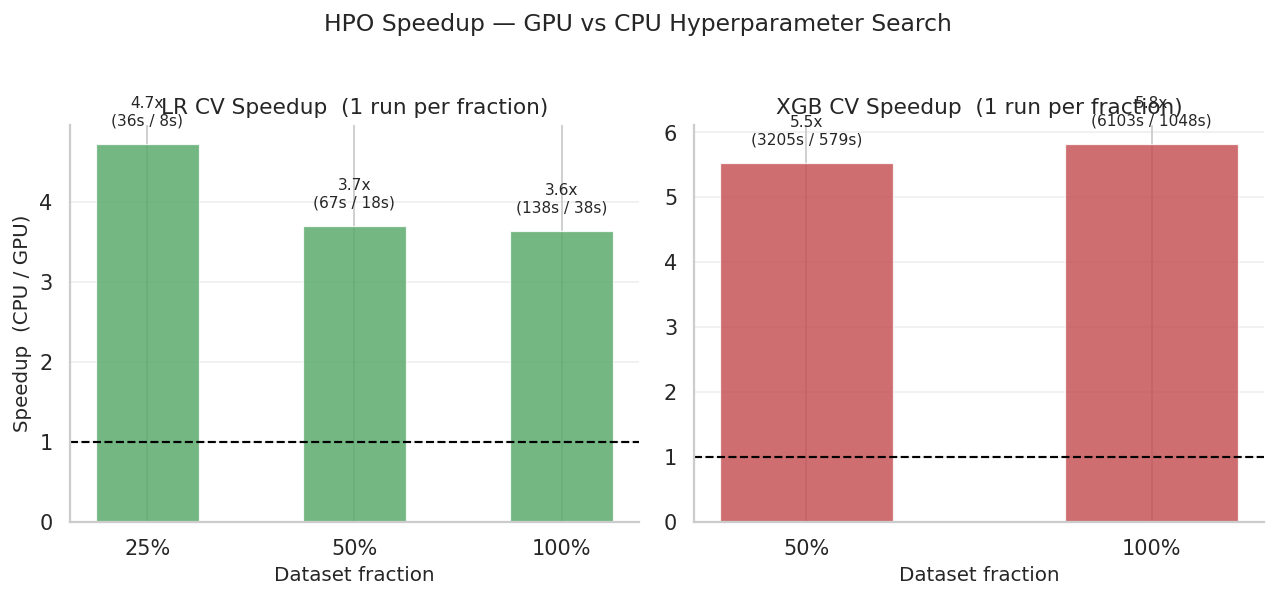

Saved  results/fig4_hpo_speedup.png


In [9]:
if not hpo_available:
    print('HPO rows not yet available — run section 5.3 in both sweep notebooks first.')
    print('Expected: phase in {lr_cv, xgb_cv}, fraction in {0.25, 0.50, 1.00}, run_idx=0')
else:
    cpu_hpo_med = cpu_hpo.groupby(['fraction', 'phase'])['seconds'].median().rename('cpu_s')
    gpu_hpo_med = gpu_hpo.groupby(['fraction', 'phase'])['seconds'].median().rename('gpu_s')
    # Inner join: only plot (fraction, phase) pairs where both CPU and GPU data exist.
    # GPU xgb_cv runs at 50% and 100% only; CPU has an extra 25% row that is dropped here.
    df_hpo = pd.concat([cpu_hpo_med, gpu_hpo_med], axis=1, join='inner').reset_index()
    df_hpo['speedup'] = df_hpo['cpu_s'] / df_hpo['gpu_s']

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=False)

    for ax, phase in zip(axes, HPO_PHASES):
        sub     = df_hpo[df_hpo['phase'] == phase].sort_values('fraction')
        pct_hpo = [f'{int(f*100)}%' for f in sub['fraction']]
        bars    = ax.bar(pct_hpo, sub['speedup'],
                         color=HPO_COLORS[phase], alpha=0.82,
                         edgecolor='white', linewidth=0.7, width=0.5)
        y_max = sub['speedup'].max()
        for bar, sp, ct, gt in zip(bars, sub['speedup'], sub['cpu_s'], sub['gpu_s']):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + y_max * 0.04,
                f'{sp:.1f}x\n({ct:.0f}s / {gt:.0f}s)',
                ha='center', va='bottom', fontsize=8.5
            )
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2)
        ax.set_title(f'{HPO_LABEL[phase]} Speedup  (1 run per fraction)', fontsize=12)
        ax.set_xlabel('Dataset fraction', fontsize=11)
        if phase == HPO_PHASES[0]:
            ax.set_ylabel('Speedup  (CPU / GPU)', fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('HPO Speedup — GPU vs CPU Hyperparameter Search', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('results/fig4_hpo_speedup.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved  results/fig4_hpo_speedup.png')

## 9. Figure 5: H2D Amortisation

Host-to-device (H2D) data transfer is one of the main costs that distinguishes a GPU
workflow from a CPU one: any data fed to a GPU kernel must first be copied across the PCIe
bus. During `RandomizedSearchCV` with 300 fits, XGBoost re-copies the feature matrix to
GPU memory on every fit when the input is a pandas DataFrame. Pre-converting the matrix to
cuDF once before the CV loop turns this into a one-time cost; this is what we mean by
*amortising* the H2D overhead.

The experiment is run once on the full (100%) dataset in `GPU_Solution.ipynb` and the two
timings are stored in `best_params.json` under the `h2d_amortisation` key.

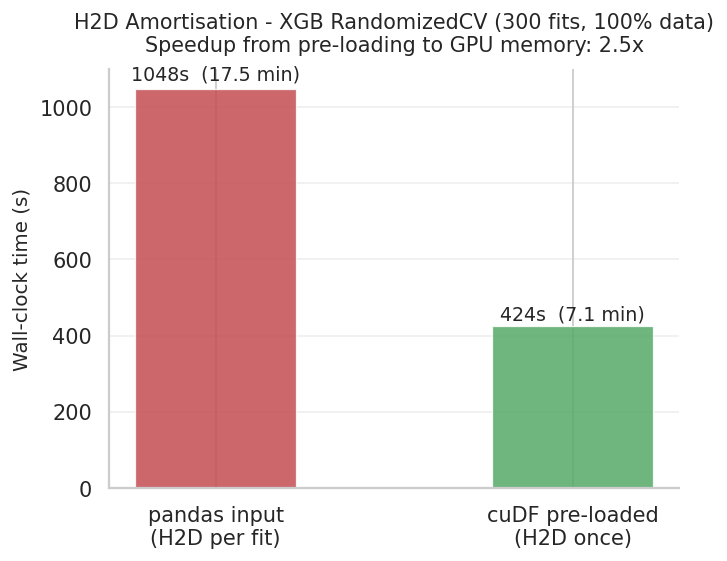

Saved  results/fig5_h2d_amortisation.png


In [10]:
if not h2d_available:
    print('H2D amortisation data not in best_params.json yet.')
    print("Expected: bp['h2d_amortisation'] = {'xgb_cv_pandas_s': ..., 'xgb_cv_cudf_s': ...}")
else:
    h2d    = bp['h2d_amortisation']
    t_pd   = h2d['xgb_cv_pandas_s']
    t_cudf = h2d['xgb_cv_cudf_s']
    sp_h2d = t_pd / t_cudf

    labels = ['pandas input\n(H2D per fit)', 'cuDF pre-loaded\n(H2D once)']
    vals   = [t_pd, t_cudf]

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    bars = ax.bar(labels, vals, color=['#C44E52', '#55A868'],
                  alpha=0.85, edgecolor='white', linewidth=0.7, width=0.45)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val * 1.015,
                f'{val:.0f}s  ({val / 60:.1f} min)',
                ha='center', va='bottom', fontsize=10.5)

    title_line1 = 'H2D Amortisation - XGB RandomizedCV (300 fits, 100% data)'
    title_line2 = f'Speedup from pre-loading to GPU memory: {sp_h2d:.1f}x'
    ax.set_title(title_line1 + '\n' + title_line2, fontsize=11.5, pad=10)
    ax.set_ylabel('Wall-clock time (s)', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('results/fig5_h2d_amortisation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved  results/fig5_h2d_amortisation.png')

## 10. CV Context Summary

Single-run timings on the full (100%) dataset, reported separately from the 3-run sweep.
They quantify the cost of hyperparameter search (the most compute-intensive part of the
pipeline) and motivate GPU acceleration before the sweep numbers come in.

In [11]:
cv_ctx     = bp['cv_context_seconds']
lr_cpu_cv  = cv_ctx['lr_gridsearch']
xgb_cpu_cv = cv_ctx['xgb_randomizedsearch']
xgb_gpu_cv = cv_ctx.get('xgb_randomizedsearch_gpu')

print('Full CV Context Timings  (100% dataset, 1 run)')
print('-' * 62)
print(f'LR  GridSearchCV   (25 fits)')
print(f'  CPU : {lr_cpu_cv:>7.1f}s  ({lr_cpu_cv / 60:.1f} min)')
print(f'  GPU : N/A  (cuML LR has no sklearn-compatible CV wrapper)')
print()
print(f'XGB RandomizedCV   (300 fits)')
print(f'  CPU : {xgb_cpu_cv:>7.1f}s  ({xgb_cpu_cv / 60:.1f} min)')
if xgb_gpu_cv:
    sp_cv = xgb_cpu_cv / xgb_gpu_cv
    print(f'  GPU : {xgb_gpu_cv:>7.1f}s  ({xgb_gpu_cv / 60:.1f} min)')
    print(f'  Speedup: {sp_cv:.1f}x')
else:
    print(f'  GPU : [fill in after GPU_Solution.ipynb run]')

Full CV Context Timings  (100% dataset, 1 run)
--------------------------------------------------------------
LR  GridSearchCV   (25 fits)
  CPU :   138.1s  (2.3 min)
  GPU : N/A  (cuML LR has no sklearn-compatible CV wrapper)

XGB RandomizedCV   (300 fits)
  CPU :  6079.9s  (101.3 min)
  GPU :  1047.5s  (17.5 min)
  Speedup: 5.8x


## 11. Full-Dataset Summary

Copy-paste-ready numbers for the report. Per-phase detail and stage-level aggregates at
100% of the training data, plus the full pipeline total speedup.

In [12]:
full = df[df['fraction'] == 1.00].set_index('phase').reindex(PHASE_ORDER)

print('100% Dataset — Per-Phase Median')
print(f'{"Phase":<14} {"CPU (s)":>10} {"GPU (s)":>10} {"Speedup":>10}')
print('-' * 48)
for phase, row in full.iterrows():
    print(f'{PHASE_LABEL[phase]:<14} {row["cpu_s"]:>10.3f} {row["gpu_s"]:>10.3f} {row["speedup"]:>9.2f}x')

# Stage aggregates at 100%
print()
print('100% Dataset — Stage Totals')
print(f'{"Stage":<20} {"CPU (s)":>10} {"GPU (s)":>10} {"Speedup":>10}')
print('-' * 52)
stage_100 = df_stages[df_stages['fraction'] == 1.00].set_index('stage')
for stage in ['Feature Eng.', 'Model Training', 'Model Inference']:
    r = stage_100.loc[stage]
    print(f'{stage:<20} {r["cpu_s"]:>10.3f} {r["gpu_s"]:>10.3f} {r["speedup"]:>9.2f}x')

# Full pipeline total
cpu_pipe = full['cpu_s'].sum()
gpu_pipe = full['gpu_s'].sum()
print('-' * 52)
print(f'{"Full pipeline":<20} {cpu_pipe:>10.3f} {gpu_pipe:>10.3f} {cpu_pipe / gpu_pipe:>9.2f}x')

100% Dataset — Per-Phase Median
Phase             CPU (s)    GPU (s)    Speedup
------------------------------------------------
FE Train            9.272      4.180      2.22x
FE Test             1.864      1.150      1.62x
LR Fit              6.860      1.481      4.63x
LR Predict          0.119      0.039      3.07x
XGB Fit            22.553      4.615      4.89x
XGB Predict         0.703      0.151      4.66x

100% Dataset — Stage Totals
Stage                   CPU (s)    GPU (s)    Speedup
----------------------------------------------------
Feature Eng.             11.136      5.329      2.09x
Model Training           29.413      6.096      4.82x
Model Inference           0.822      0.190      4.33x
----------------------------------------------------
Full pipeline            41.371     11.615      3.56x
